# 03 · Descriptive (Unsupervised) Analytics
**Process-model step:** *Analyse the data — descriptive* (Fraud Analytics ch. 3)
**AML concept:** peer groups & customer segmentation (Chau ch. 8), statistical outliers as scenario logic (ch. 9)
**Statistics (*Practical Statistics* ch. 7):** PCA, k-means, hierarchical clustering, choosing k, scaling & mixed data · plus permutation tests for break points

Descriptive analytics needs **no fraud label**: we look for *unusual patterns* — outliers, break points, deviating peers, rare combinations. Its weakness is that "unusual" ≠ "suspicious", and it is hard to evaluate. In this lab we can grade every method against the oracle; in real life you grade with analyst feedback and mock investigations.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from scipy import stats
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score, roc_auc_score
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from statsmodels.stats.multitest import multipletests
import amlkit as ak

pd.set_option("display.float_format", "{:,.3f}".format); pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid")

txn = pd.read_pickle(ak.PROC / "txn_clean.pkl")
feat = pd.read_pickle(ak.PROC / "features.pkl")
y = feat.is_launderer.values

RESULTS = []
def evaluate(name, score):
    '''Grade an unsupervised score against the oracle (lab only).'''
    s = np.asarray(score, float); s = np.nan_to_num(s, nan=np.nanmin(s))
    o = np.argsort(-s)
    RESULTS.append(dict(method=name, AUC=roc_auc_score(y, s), **{"P@50": y[o[:50]].mean(), "P@100": y[o[:100]].mean(),
                        "recall@top5%": y[o[:int(.05 * len(y))]].sum() / y.sum()}))
    return pd.DataFrame(RESULTS[-1:]).set_index("method")
print(feat.shape, "| base rate", y.mean().round(4))

(3500, 54) | base rate 0.0351


## 1 · Peer-group analysis
Compare each customer with **similar** customers (same segment) rather than with everybody. Score = how many robust standard deviations above the peer median (robust z uses median and MAD).

In [2]:
score_cols = ["log_turnover_ratio", "log_max_cash_agg_5d", "log_amt_wire_in", "hr_share", "near_ctr_cnt", "flowthrough_max"]

def robust_z(df, col, by=None):
    g = df.groupby(by)[col] if by else None
    med = g.transform("median") if by else df[col].median()
    mad = (g.transform(lambda s: stats.median_abs_deviation(s, scale="normal")) if by
           else stats.median_abs_deviation(df[col], scale="normal"))
    floor = 0.1 * df[col].std()                          # zero-inflated features have MAD = 0 -> floor
    return (df[col] - med) / np.maximum(mad, floor)

global_score = sum(robust_z(feat, c).clip(0, 10) for c in score_cols)
peer_score   = sum(robust_z(feat, c, by="segment").clip(0, 10) for c in score_cols)

print(pd.concat([evaluate("Global robust-z sum", global_score), evaluate("Peer-group (segment) robust-z sum", peer_score)]))

                                    AUC  P@50  P@100  recall@top5%
method                                                            
Global robust-z sum               0.862 0.260  0.210         0.285
Peer-group (segment) robust-z sum 0.820 0.580  0.390         0.496


In [3]:
top = feat.assign(peer_score=peer_score).nlargest(15, "peer_score")[["customer_id", "segment", "monthly_credits", "turnover_ratio",
      "max_cash_agg_5d", "near_ctr_cnt", "flowthrough_max", "peer_score", "is_launderer", "typology"]]
top

,customer_id,segment,monthly_credits,turnover_ratio,max_cash_agg_5d,near_ctr_cnt,flowthrough_max,peer_score,is_launderer,typology
301,301,retail_salaried,"31,149.490",14.455,"62,817.230",41.000,0.178,35.688,1,structuring
2653,2653,retail_self_employed,"34,818.990",61.086,"2,431.850",0.000,0.998,33.300,1,pass_through
2967,2967,retail_salaried,"23,561.307",27.397,"53,870.890",31.000,0.301,32.155,1,structuring
3098,3098,retail_salaried,"26,662.188",14.335,"1,099.370",0.000,0.973,31.380,1,pass_through
839,839,retail_salaried,"33,985.528",16.993,"104,616.800",44.000,0.242,31.155,1,structuring
2381,2381,retail_salaried,"25,788.278",10.274,"53,989.640",31.000,0.264,31.100,1,structuring
587,587,retail_salaried,"26,201.111",7.798,"2,924.010",0.000,0.968,29.786,1,pass_through
634,634,retail_salaried,"29,240.682",13.569,"51,944.730",38.000,0.234,29.178,1,structuring
2989,2989,retail_self_employed,"25,957.154",6.656,"5,365.380",0.000,0.984,28.961,1,pass_through
585,585,retail_self_employed,"13,332.067",1.720,"12,101.080",2.000,0.626,28.758,0,none


Peer grouping sharpens the **top of the ranking** (precision@50 — what analysts actually work through) even though the whole-ranking AUC is not better. It works because **normal behaviour differs by segment** — the same reason AML ch. 8 says thresholds must be set per segment. But also note the limit: a launderer *inside* a peer group of launderers (or a badly-defined segment) hides in plain sight.

## 2 · Break-point analysis
Has a customer's behaviour **changed abruptly**? (commingling: cash deposits jump when illicit money is mixed with legitimate turnover.) Method: for each customer scan every possible split of the weekly cash-deposit **count** series (square-root transformed to stabilise variance; customers with ≥ 50 deposits so the series is dense), take the largest Welch *t*-statistic, and get a p-value by **permutation** (shuffle the weeks → no structure). The null distribution is **pooled** over all customers' shuffles (with only ~50 shuffles per customer the smallest per-customer p-value could never survive a multiple-testing correction over hundreds of customers). One test per customer → Benjamini–Hochberg FDR.

In [4]:
cd = txn[txn.channel == "cash_deposit"].copy()
cd["week"] = np.minimum(cd.day // 7, 51)
W = cd.pivot_table(index="customer_id", columns="week", values="amount_usd", aggfunc="count", fill_value=0).reindex(feat.customer_id, fill_value=0)
W = W.reindex(columns=range(52), fill_value=0)
n_dep = feat.set_index("customer_id").n_cash_dep.reindex(W.index)
X = np.sqrt(W.values)                     # variance-stabilising transform for counts

def max_split_t(X, kmin=8):
    T = X.shape[1]
    c1, c2 = X.cumsum(1), (X ** 2).cumsum(1)
    best, arg = np.zeros(len(X)), np.zeros(len(X), int)
    for k in range(kmin, T - kmin + 1):
        n1, n2 = k, T - k
        s1, q1 = c1[:, k - 1], c2[:, k - 1]
        s2, q2 = c1[:, -1] - s1, c2[:, -1] - q1
        m1, m2 = s1 / n1, s2 / n2
        v1, v2 = (q1 - n1 * m1 ** 2) / (n1 - 1), (q2 - n2 * m2 ** 2) / (n2 - 1)
        t = np.abs(m2 - m1) / np.sqrt(np.maximum(v1, 0) / n1 + np.maximum(v2, 0) / n2 + 1e-9)
        upd = t > best; best, arg = np.where(upd, t, best), np.where(upd, k, arg)
    return best, arg

elig = (n_dep >= 50).values                 # need a dense series for a stable test
t_obs, k_obs = max_split_t(X[elig])
rng = np.random.default_rng(0)
B = 50
null = np.concatenate([max_split_t(rng.permuted(X[elig], axis=1))[0] for _ in range(B)])       # pooled permutation null
null.sort()
pval = (1 + (len(null) - np.searchsorted(null, t_obs, side="left"))) / (len(null) + 1)

bp = pd.DataFrame({"customer_id": W.index[elig], "t": t_obs, "week": k_obs, "p": pval})
bp["q"] = multipletests(bp.p, method="fdr_bh")[1]
bp = bp.merge(feat[["customer_id", "is_launderer", "typology", "segment"]], on="customer_id")
print("customers tested:", len(bp), "| raw p<0.05:", (bp.p < .05).sum(), "| FDR q<0.05:", (bp.q < .05).sum())
sub = bp[bp.typology.isin(["commingling", "none"])]
print("AUC commingling vs non-launderers (max t as score): %.3f" % roc_auc_score(sub.typology == "commingling", sub.t))
print("AUC all launderers vs non-launderers               : %.3f  <- the break-point test is typology-specific" % roc_auc_score(bp.is_launderer, bp.t))
bp.assign(flag=bp.q < .05).groupby("typology").flag.agg(flagged="sum", tested="count")

customers tested: 572 | raw p<0.05: 51 | FDR q<0.05: 6
AUC commingling vs non-launderers (max t as score): 0.991
AUC all launderers vs non-launderers               : 0.627  <- the break-point test is typology-specific


,flagged,tested
typology,,
commingling,6,14
mule_ring,0,11
none,0,496
pass_through,0,7
smurfing_low,0,19
structuring,0,25


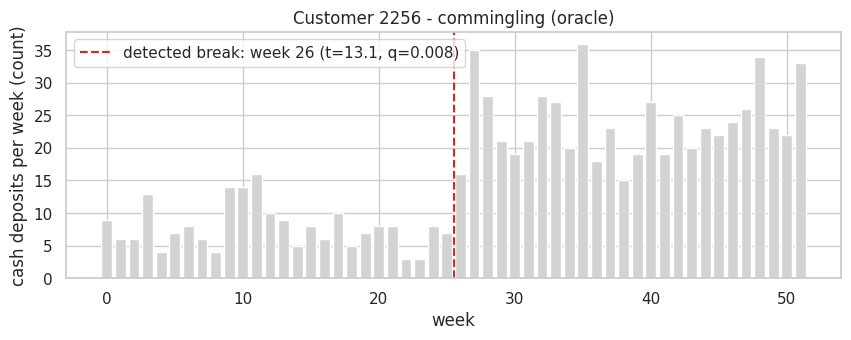

,AUC,P@50,P@100,recall@top5%
method,,,,
Break-point (max split t),0.747,0.340,0.220,0.252


In [5]:
ex = bp[bp.typology == "commingling"].nlargest(1, "t").iloc[0]
s = W.loc[int(ex.customer_id)].values
fig, ax = plt.subplots(figsize=(10, 3.2))
ax.bar(range(52), s, color="lightgrey"); ax.axvline(ex.week - 0.5, color="tab:red", ls="--", label=f"detected break: week {int(ex.week)} (t={ex.t:.1f}, q={ex.q:.3f})")
ax.set(xlabel="week", ylabel="cash deposits per week (count)", title=f"Customer {int(ex.customer_id)} - commingling (oracle)"); ax.legend(); plt.show()
evaluate("Break-point (max split t)", bp.set_index("customer_id").t.reindex(feat.customer_id).fillna(0).values)

The permutation null makes no distributional assumptions but **does** assume weeks are exchangeable; real data with seasonality (Khmer New Year, harvest, month-end) needs a seasonal adjustment first, or you'll flag half the cash-intensive businesses.

## 3 · Clustering and segmentation (*Practical Statistics* ch. 7)
AML ch. 8 verifies segments statistically. Let the data propose a segmentation and compare it with the declared one.

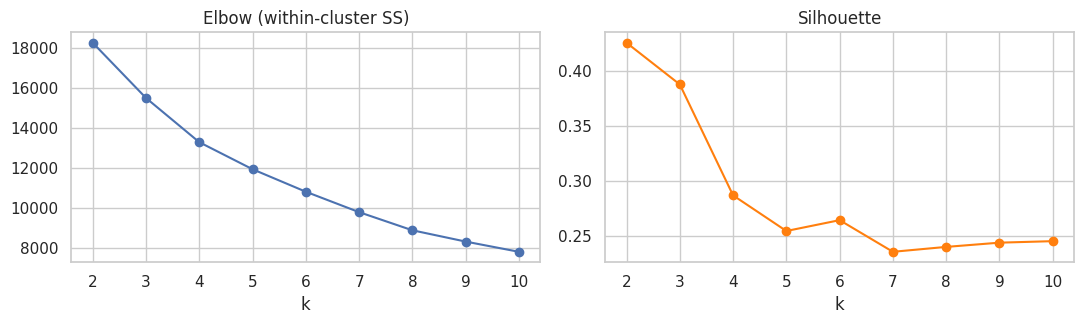

In [6]:
cl_cols = ["log_n_txn", "log_mean_amt", "log_credits", "log_amt_cash_deposit", "log_amt_wire_in", "cash_share_credits",
           "log_n_counterparties", "night_share", "hr_share"]
Xc = StandardScaler().fit_transform(feat[cl_cols])

ks = range(2, 11)
inertia, sil = [], []
for k in ks:
    km = KMeans(k, n_init=10, random_state=0).fit(Xc)
    inertia.append(km.inertia_); sil.append(silhouette_score(Xc, km.labels_, sample_size=2000, random_state=0))
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].plot(ks, inertia, "o-"); ax[0].set(title="Elbow (within-cluster SS)", xlabel="k")
ax[1].plot(ks, sil, "o-", color="tab:orange"); ax[1].set(title="Silhouette", xlabel="k")
plt.tight_layout(); plt.show()

In [7]:
K = 5
km = KMeans(K, n_init=20, random_state=0).fit(Xc)
feat["cluster"] = km.labels_
print("Adjusted Rand Index vs declared segment:", round(adjusted_rand_score(feat.segment, feat.cluster), 3))
print(pd.crosstab(feat.segment, feat.cluster))
prof = feat.groupby("cluster").agg(customers=("customer_id", "size"), median_credits=("monthly_credits", "median"),
        cash_share=("cash_share_credits", "mean"), wire_in=("amt_wire_in", "median"), launderer_rate=("is_launderer", "mean"))
prof

Adjusted Rand Index vs declared segment: 0.241
cluster                 0    1    2    3    4
segment                                      
cash_intensive        241    0    3    0    0
corporate               0    0  177    0    0
retail_salaried        19  548    4  600  756
retail_self_employed  101  185    7   22  368
small_business        449    2    7    0   11


,customers,median_credits,cash_share,wire_in,launderer_rate
cluster,,,,,
0,810,"33,200.826",0.436,"109,434.630",0.111
1,735,"2,460.158",0.175,"4,415.430",0.000
2,198,"258,547.836",0.045,"2,541,011.455",0.116
3,622,"1,477.792",0.182,0.000,0.003
4,1135,"3,102.494",0.199,"5,663.270",0.007


Clusters that differ from the declared segments show where **KYC segmentation and behaviour disagree** — candidates for re-segmentation (AML ch. 8: *Change of segmentation*). Distance to one's own cluster centre is another outlier score:

In [8]:
dist = np.linalg.norm(Xc - km.cluster_centers_[km.labels_], axis=1)
evaluate("k-means distance to centroid", dist)

,AUC,P@50,P@100,recall@top5%
method,,,,
k-means distance to centroid,0.764,0.380,0.270,0.358


### Hierarchical clustering (Ward) on a sample — dendrogram

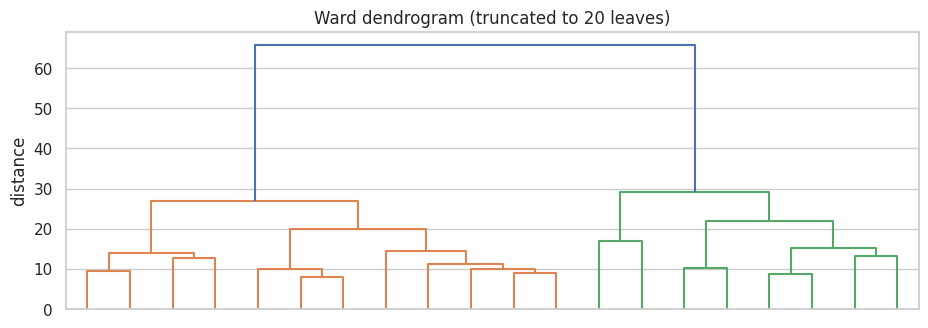

{1: 102, 2: 298, 3: 24, 4: 46, 5: 130}


In [9]:
samp = feat.sample(600, random_state=2)
Z = linkage(StandardScaler().fit_transform(samp[cl_cols]), method="ward")
fig, ax = plt.subplots(figsize=(11, 3.6))
dendrogram(Z, truncate_mode="lastp", p=20, ax=ax, no_labels=True); ax.set(title="Ward dendrogram (truncated to 20 leaves)", ylabel="distance"); plt.show()
print(pd.Series(fcluster(Z, 5, "maxclust")).value_counts().sort_index().to_dict())

## 4 · Multivariate anomaly detection: Isolation Forest & One-class SVM
Fraud Analytics ch. 3 introduces one-class SVMs for describing "normal" behaviour. Isolation Forest is a fast, scale-tolerant alternative: anomalies are isolated in fewer random splits. Try **global** vs **per-segment** models.

In [10]:
Xa = feat[cl_cols + ["log_max_cash_agg_5d", "log_turnover_ratio", "flowthrough_max", "near_ctr_cnt"]]
Xa_s = StandardScaler().fit_transform(Xa)

iso = IsolationForest(n_estimators=300, random_state=0).fit(Xa_s)
s_iso = -iso.score_samples(Xa_s)

s_iso_seg = np.zeros(len(feat))
for seg, idx in feat.groupby("segment").indices.items():
    Xs = StandardScaler().fit_transform(Xa.iloc[idx])
    s_iso_seg[idx] = pd.Series(-IsolationForest(n_estimators=300, random_state=0).fit(Xs).score_samples(Xs)).rank(pct=True).values

ocsvm = OneClassSVM(kernel="rbf", nu=0.05, gamma="scale").fit(Xa_s)
s_svm = -ocsvm.decision_function(Xa_s)

pd.concat([evaluate("Isolation Forest (global)", s_iso), evaluate("Isolation Forest (per segment, pct rank)", s_iso_seg),
           evaluate("One-class SVM (rbf)", s_svm)])

,AUC,P@50,P@100,recall@top5%
method,,,,
Isolation Forest (global),0.907,0.580,0.450,0.472
"Isolation Forest (per segment, pct rank)",0.837,0.700,0.470,0.472
One-class SVM (rbf),0.869,0.760,0.520,0.537


## 5 · Association analysis on red flags
Which flags co-occur more than chance? For flags A and B: **support** = P(A∧B), **confidence** = P(B|A), **lift** = P(A∧B) / (P(A)P(B)). Lift > 1 means positive association (used in the AML book for scenario-overlap analysis — ch. 6 "overlapping scenario rules").

In [11]:
flags = pd.DataFrame({
    "near_ctr": feat.near_ctr_cnt >= 3, "cash_burst": feat.max_cash_agg_5d >= ak.CTR_THRESHOLD, "turnover_3x": feat.turnover_ratio > 3,
    "flowthrough": feat.flowthrough_max >= 0.9, "high_risk_cty": feat.hr_share > 0.05, "suspicious(oracle)": feat.is_launderer == 1})
rows = []
cols = list(flags.columns)
for i, a in enumerate(cols):
    for b in cols[i + 1:]:
        sup = (flags[a] & flags[b]).mean()
        rows.append(dict(A=a, B=b, support=sup, conf_A_to_B=sup / flags[a].mean(), lift=sup / (flags[a].mean() * flags[b].mean())))
pd.DataFrame(rows).sort_values("lift", ascending=False).head(10)

,A,B,support,conf_A_to_B,lift
11,turnover_3x,suspicious(oracle),0.009,0.582,16.556
4,near_ctr,suspicious(oracle),0.019,0.241,6.854
1,near_ctr,turnover_3x,0.005,0.069,4.413
0,near_ctr,cash_burst,0.078,1.000,4.342
2,near_ctr,flowthrough,0.052,0.668,4.305
6,cash_burst,flowthrough,0.133,0.578,3.727
8,cash_burst,suspicious(oracle),0.029,0.124,3.530
13,flowthrough,suspicious(oracle),0.016,0.105,2.987
12,flowthrough,high_risk_cty,0.083,0.532,2.538
5,cash_burst,turnover_3x,0.009,0.040,2.527


## 6 · Compare the descriptive methods

In [12]:
res = pd.DataFrame(RESULTS).set_index("method").sort_values("AUC", ascending=False)
print(f"base rate = {y.mean():.3f}  (random top-50 precision ~ {y.mean():.3f})")
res.style.format("{:.3f}").background_gradient(cmap="Greens", subset=["AUC", "P@50", "P@100", "recall@top5%"])

base rate = 0.035  (random top-50 precision ~ 0.035)


,AUC,P@50,P@100,recall@top5%
method,,,,
Isolation Forest (global),0.907,0.580,0.450,0.472
One-class SVM (rbf),0.869,0.760,0.520,0.537
Global robust-z sum,0.862,0.260,0.210,0.285
"Isolation Forest (per segment, pct rank)",0.837,0.700,0.470,0.472
Peer-group (segment) robust-z sum,0.820,0.580,0.390,0.496
k-means distance to centroid,0.764,0.380,0.270,0.358
Break-point (max split t),0.747,0.340,0.220,0.252


### Reading the table
* No single method wins on every typology: **break-point** finds commingling; **peer-group** and **isolation** find volume/velocity anomalies; **Benford** (notebook 02) finds structuring.
* Descriptive scores are good **triage generators and feature sources**; feed them into supervised models (notebook 06) once you have labels.
* *Always* record why a customer was flagged (reason codes) — investigators and regulators need explanations.

### Exercises
1. Change the peer-group definition from `segment` to `cluster` — does precision@50 improve?
2. Replace the break-point scan with monthly totals and a Mann-Whitney test between H1 and H2; compare power.
3. Add a *seasonality adjustment* (subtract each week's segment median) before the break-point test.

**Next → `04_aml_threshold_tuning_workflow`**